In [1]:
import pandas as pd


In [2]:
import os
print(os.getcwd())

c:\Users\omala\Projects\Project1_procurement-fraud-detection\notebooks


In [3]:
print(os.listdir("../archive"))

['Procument Invoice Fraud Dataset v1']


In [4]:
invoices = pd.read_parquet("../archive/Procument Invoice Fraud Dataset v1/invoices.parquet")

In [5]:
invoices.head()

,invoice_id,supplier_id,department_id,invoice_date,invoice_amount,currency,payment_terms,invoice_type,submission_hour,image_path
0,INV_0000000,7316ce64-2a14-4a96-9b0c-62eb27c8fc6c,DPT_025,2023-04-18,3565.57,ZAR,NET60,GOODS,18,data/v1/20251214_172643/images/INV_0000000.png
1,INV_0000001,7428a656-b3ee-4d3b-9a10-412954aebd1b,DPT_010,2023-10-08,9871.78,ZAR,NET30,SERVICES,6,NaN
2,INV_0000002,7b0ccad9-eee1-4cae-b02e-21aa352b6ec8,DPT_041,2023-09-24,8530.64,ZAR,NET60,SERVICES,23,NaN
3,INV_0000003,1c6345ab-6e0e-41e8-985d-3f861d2324e6,DPT_015,2023-10-15,1378.52,ZAR,NET30,GOODS,7,NaN
4,INV_0000004,22d839d3-33e4-4986-b18c-ccdc131eb723,DPT_039,2023-06-07,2373.66,ZAR,NET30,GOODS,12,NaN


In [6]:
invoices.shape

(300000, 10)

In [7]:
invoices.columns

Index(['invoice_id', 'supplier_id', 'department_id', 'invoice_date',
       'invoice_amount', 'currency', 'payment_terms', 'invoice_type',
       'submission_hour', 'image_path'],
      dtype='str')

In [8]:
invoices.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   invoice_id       300000 non-null  str           
 1   supplier_id      300000 non-null  str           
 2   department_id    300000 non-null  str           
 3   invoice_date     300000 non-null  datetime64[ns]
 4   invoice_amount   300000 non-null  float64       
 5   currency         300000 non-null  str           
 6   payment_terms    300000 non-null  str           
 7   invoice_type     300000 non-null  str           
 8   submission_hour  300000 non-null  int64         
 9   image_path       45000 non-null   str           
dtypes: datetime64[ns](1), float64(1), int64(1), str(7)
memory usage: 44.5 MB


In [9]:
print(os.listdir("../archive/Procument Invoice Fraud Dataset v1"))

['behavioural_features.parquet', 'departments.parquet', 'images', 'images_metadata.parquet', 'invoices.parquet', 'labels.parquet', 'manifest.json', 'splits.parquet', 'suppliers.parquet']


In [10]:
labels = pd.read_parquet("../archive/Procument Invoice Fraud Dataset v1/labels.parquet")

In [11]:
labels.head()

,invoice_id,is_fraud,fraud_type,fraud_tags,explanations
0,INV_0000000,0,NONE,,"{""reason"": ""NONE""}"
1,INV_0000001,0,NONE,,"{""reason"": ""NONE""}"
2,INV_0000002,0,NONE,,"{""reason"": ""NONE""}"
3,INV_0000003,1,SPLIT,SPLIT,"{""rules"": [""SPLIT""]}"
4,INV_0000004,0,NONE,,"{""reason"": ""NONE""}"


In [12]:
labels["is_fraud"].value_counts()

is_fraud
0    233590
1     66410
Name: count, dtype: int64

In [13]:
labels["is_fraud"].value_counts(normalize=True) * 100

is_fraud
0    77.863333
1    22.136667
Name: proportion, dtype: float64

In [14]:
labels["fraud_type"].value_counts()

fraud_type
NONE              237036
SPLIT              42346
GHOST_SUPPLIER     12588
INFLATED            5581
DOC_TAMPER          2379
DUPLICATE             70
Name: count, dtype: int64

In [15]:
pd.crosstab(labels["is_fraud"], labels["fraud_type"])

fraud_type,DOC_TAMPER,DUPLICATE,GHOST_SUPPLIER,INFLATED,NONE,SPLIT
is_fraud,,,,,,
0,49,0,244,115,232313,869
1,2330,70,12344,5466,4723,41477


In [16]:
import json

with open("../archive/Procument Invoice Fraud Dataset v1/manifest.json", "r") as file:
    manifest = json.load(file)

manifest

{'version': 'v1',
 'generated_utc': '20251214_172643',
 'counts': {'suppliers': 2000,
  'departments': 50,
  'invoices': 300000,
  'behavioural_features': 300000,
  'labels': 300000,
  'images': 45000},
 'format': 'parquet'}

In [17]:
suppliers = pd.read_parquet("../archive/Procument Invoice Fraud Dataset v1/suppliers.parquet")
suppliers.head()

,supplier_id,supplier_country,supplier_age_days,supplier_risk_score,blacklisted_flag,avg_invoice_amount
0,fc3e058b-e0f3-4ab0-9cec-4eb5edd96831,SV,841,0.244,0,5590.25
1,3d4cbf37-4eb9-4eff-8e88-cb2dd4e80839,KE,61,0.284,0,5797.64
2,913e4de2-e0c5-4cb8-bda9-c2a90ed42f1a,YE,197,0.390,0,897.65
3,bb5e4bcf-15ed-4269-9429-6c07f26b4776,SA,851,0.299,0,7727.71
4,fa5d3100-11b7-4948-90e6-e6607c69dee1,DJ,4373,0.418,0,5458.67


In [18]:
suppliers.shape

(2000, 6)

In [19]:
suppliers.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   supplier_id          2000 non-null   str    
 1   supplier_country     2000 non-null   str    
 2   supplier_age_days    2000 non-null   int64  
 3   supplier_risk_score  2000 non-null   float64
 4   blacklisted_flag     2000 non-null   int64  
 5   avg_invoice_amount   2000 non-null   float64
dtypes: float64(2), int64(2), str(2)
memory usage: 168.1 KB


In [20]:
behaviour = pd.read_parquet("../archive/Procument Invoice Fraud Dataset v1/behavioural_features.parquet")
behaviour.head()

,invoice_id,supplier_invoice_count_30d,supplier_avg_amount_90d,invoice_amount_zscore,duplicate_invoice_flag,split_invoice_flag,late_night_submission_flag
0,INV_0138003,1.0,4252.160000,-0.375908,0,0,0
1,INV_0153155,2.0,13972.275000,1.830169,0,0,0
2,INV_0034829,3.0,17737.206667,2.008863,0,0,0
3,INV_0072998,4.0,14480.340000,-0.323982,0,1,0
4,INV_0211525,5.0,12515.048000,-0.330321,0,1,0


In [21]:
behaviour.shape

(300000, 7)

In [22]:
behaviour.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 7 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   invoice_id                  300000 non-null  str    
 1   supplier_invoice_count_30d  300000 non-null  float64
 2   supplier_avg_amount_90d     300000 non-null  float64
 3   invoice_amount_zscore       300000 non-null  float64
 4   duplicate_invoice_flag      300000 non-null  int64  
 5   split_invoice_flag          300000 non-null  int64  
 6   late_night_submission_flag  300000 non-null  int64  
dtypes: float64(3), int64(3), str(1)
memory usage: 19.2 MB


In [23]:
pd.crosstab(
    behaviour["split_invoice_flag"],
    labels["fraud_type"]
)

fraud_type,DOC_TAMPER,DUPLICATE,GHOST_SUPPLIER,INFLATED,NONE,SPLIT
split_invoice_flag,,,,,,
0,2029,63,10749,4799,203303,36378
1,350,7,1839,782,33733,5968


In [24]:
behaviour_labels = behaviour.merge(labels, on="invoice_id")
behaviour_labels.shape

(300000, 11)

In [25]:
pd.crosstab(
    behaviour_labels["split_invoice_flag"],
    behaviour_labels["fraud_type"]
)

fraud_type,DOC_TAMPER,DUPLICATE,GHOST_SUPPLIER,INFLATED,NONE,SPLIT
split_invoice_flag,,,,,,
0,2054,62,12588,5581,237036,0
1,325,8,0,0,0,42346


In [26]:
pd.crosstab(
    behaviour_labels["duplicate_invoice_flag"],
    behaviour_labels["fraud_type"]
)

fraud_type,DOC_TAMPER,DUPLICATE,GHOST_SUPPLIER,INFLATED,NONE,SPLIT
duplicate_invoice_flag,,,,,,
0,2379,0,12588,5581,237036,42346
1,0,70,0,0,0,0


In [27]:
pd.crosstab(
    behaviour_labels["late_night_submission_flag"],
    behaviour_labels["fraud_type"]
)

fraud_type,DOC_TAMPER,DUPLICATE,GHOST_SUPPLIER,INFLATED,NONE,SPLIT
late_night_submission_flag,,,,,,
0,0,53,9515,4266,179044,31958
1,2379,17,3073,1315,57992,10388


In [28]:
behaviour[
    ["supplier_invoice_count_30d", "supplier_avg_amount_90d", "invoice_amount_zscore"]
].describe()

,supplier_invoice_count_30d,supplier_avg_amount_90d,invoice_amount_zscore
count,300000.000000,300000.000000,3.000000e+05
mean,12.635893,7572.864589,5.835924e-17
std,3.918758,6240.050468,1.000002e+00
min,1.000000,193.330000,-8.542044e-01
25%,10.000000,3654.072531,-5.586563e-01
50%,13.000000,5767.308586,-3.032648e-01
75%,15.000000,9358.080053,1.817357e-01
max,31.000000,294048.720000,3.251019e+01


In [29]:
behaviour_labels.groupby("fraud_type")["invoice_amount_zscore"].mean()

fraud_type
DOC_TAMPER        0.120010
DUPLICATE        -0.365467
GHOST_SUPPLIER    0.025025
INFLATED          4.829157
NONE             -0.015811
SPLIT            -0.561531
Name: invoice_amount_zscore, dtype: float64

In [30]:
behaviour_labels.groupby("fraud_type")["invoice_amount_zscore"].describe()

,count,mean,std,min,25%,50%,75%,max
fraud_type,,,,,,,,
DOC_TAMPER,2379.0,0.120010,1.248795,-0.827889,-0.556041,-0.289844,0.253961,14.851054
DUPLICATE,70.0,-0.365467,0.625041,-0.801975,-0.719636,-0.574028,-0.329359,2.148827
GHOST_SUPPLIER,12588.0,0.025025,0.708004,-0.840584,-0.464670,-0.207219,0.278993,2.999807
INFLATED,5581.0,4.829157,2.277333,3.001025,3.444005,4.079076,5.344173,32.510194
NONE,237036.0,-0.015811,0.695382,-0.842324,-0.503718,-0.237980,0.238844,2.999620
SPLIT,42346.0,-0.561531,0.256211,-0.854204,-0.722385,-0.635278,-0.489157,3.020892


In [31]:
behaviour_labels.groupby("fraud_type")["supplier_invoice_count_30d"].mean()

fraud_type
DOC_TAMPER        12.880622
DUPLICATE         12.014286
GHOST_SUPPLIER    12.753257
INFLATED          12.585917
NONE              12.575883
SPLIT             12.930784
Name: supplier_invoice_count_30d, dtype: float64

In [32]:
behaviour_labels.groupby("fraud_type")["supplier_avg_amount_90d"].mean()

fraud_type
DOC_TAMPER         8839.521104
DUPLICATE          4744.668999
GHOST_SUPPLIER     7561.078345
INFLATED          25695.999722
NONE               7112.508680
SPLIT              7698.228708
Name: supplier_avg_amount_90d, dtype: float64

In [33]:
departments = pd.read_parquet("../archive/Procument Invoice Fraud Dataset v1/departments.parquet")

departments.head()

,department_id,region,annual_budget
0,DPT_000,Rhode Island,3.278881e+08
1,DPT_001,Arkansas,2.666879e+07
2,DPT_002,Nevada,1.491465e+07
3,DPT_003,New York,4.204102e+08
4,DPT_004,Louisiana,2.956358e+08


In [34]:
departments.shape

(50, 3)

In [35]:
departments.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   department_id  50 non-null     str    
 1   region         50 non-null     str    
 2   annual_budget  50 non-null     float64
dtypes: float64(1), str(2)
memory usage: 2.1 KB


In [36]:
splits = pd.read_parquet("../archive/Procument Invoice Fraud Dataset v1/splits.parquet")

splits.head()

,invoice_id,split
0,INV_0258729,train
1,INV_0179434,train
2,INV_0123072,train
3,INV_0031388,train
4,INV_0205955,train


In [37]:
splits.shape

(300000, 2)

In [38]:
splits.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   invoice_id  300000 non-null  str  
 1   split       300000 non-null  str  
dtypes: str(2)
memory usage: 9.0 MB


In [39]:
splits["split"].value_counts()

split
train    210000
test      60000
val       30000
Name: count, dtype: int64

In [40]:
data = invoices.merge(labels, on="invoice_id")
data.shape

(300000, 14)

In [41]:
data = data.merge(suppliers, on="supplier_id")
data.shape

(300000, 19)

In [42]:
data.columns.tolist()

['invoice_id',
 'supplier_id',
 'department_id',
 'invoice_date',
 'invoice_amount',
 'currency',
 'payment_terms',
 'invoice_type',
 'submission_hour',
 'image_path',
 'is_fraud',
 'fraud_type',
 'fraud_tags',
 'explanations',
 'supplier_country',
 'supplier_age_days',
 'supplier_risk_score',
 'blacklisted_flag',
 'avg_invoice_amount']

In [43]:
data = invoices.merge(labels, on="invoice_id")
data = data.merge(suppliers, on="supplier_id")
data.shape

(300000, 19)

In [44]:
data = data.merge(departments, on="department_id")
data.shape

(300000, 21)

In [45]:
data = data.merge(behaviour, on="invoice_id")
data.shape

(300000, 27)

In [46]:
data = data.merge(splits, on="invoice_id")
data.shape

(300000, 28)

In [47]:
data.head()

,invoice_id,supplier_id,department_id,invoice_date,invoice_amount,currency,payment_terms,invoice_type,submission_hour,image_path,...,avg_invoice_amount,region,annual_budget,supplier_invoice_count_30d,supplier_avg_amount_90d,invoice_amount_zscore,duplicate_invoice_flag,split_invoice_flag,late_night_submission_flag,split
0,INV_0000000,7316ce64-2a14-4a96-9b0c-62eb27c8fc6c,DPT_025,2023-04-18,3565.57,ZAR,NET60,GOODS,18,data/v1/20251214_172643/images/INV_0000000.png,...,4552.54,North Carolina,2.171350e+07,13.0,5417.982105,-0.453822,0,0,0,train
1,INV_0000001,7428a656-b3ee-4d3b-9a10-412954aebd1b,DPT_010,2023-10-08,9871.78,ZAR,NET30,SERVICES,6,NaN,...,5568.13,Arizona,4.778807e+08,6.0,6745.242333,0.261806,0,0,0,val
2,INV_0000002,7b0ccad9-eee1-4cae-b02e-21aa352b6ec8,DPT_041,2023-09-24,8530.64,ZAR,NET60,SERVICES,23,NaN,...,4542.37,Connecticut,5.119035e+07,13.0,4950.948095,0.109614,0,0,0,val
3,INV_0000003,1c6345ab-6e0e-41e8-985d-3f861d2324e6,DPT_015,2023-10-15,1378.52,ZAR,NET30,GOODS,7,NaN,...,2705.89,Pennsylvania,7.018474e+06,15.0,3524.075116,-0.702008,0,1,0,val
4,INV_0000004,22d839d3-33e4-4986-b18c-ccdc131eb723,DPT_039,2023-06-07,2373.66,ZAR,NET30,GOODS,12,NaN,...,3590.46,Louisiana,2.118290e+08,11.0,4670.320968,-0.589080,0,0,0,train


In [48]:
data.isnull().sum()

invoice_id                         0
supplier_id                        0
department_id                      0
invoice_date                       0
invoice_amount                     0
currency                           0
payment_terms                      0
invoice_type                       0
submission_hour                    0
image_path                    255000
is_fraud                           0
fraud_type                         0
fraud_tags                         0
explanations                       0
supplier_country                   0
supplier_age_days                  0
supplier_risk_score                0
blacklisted_flag                   0
avg_invoice_amount                 0
region                             0
annual_budget                      0
supplier_invoice_count_30d         0
supplier_avg_amount_90d            0
invoice_amount_zscore              0
duplicate_invoice_flag             0
split_invoice_flag                 0
late_night_submission_flag         0
s

## Exploratory Data Analysis

In [49]:
import matplotlib.pyplot as plt

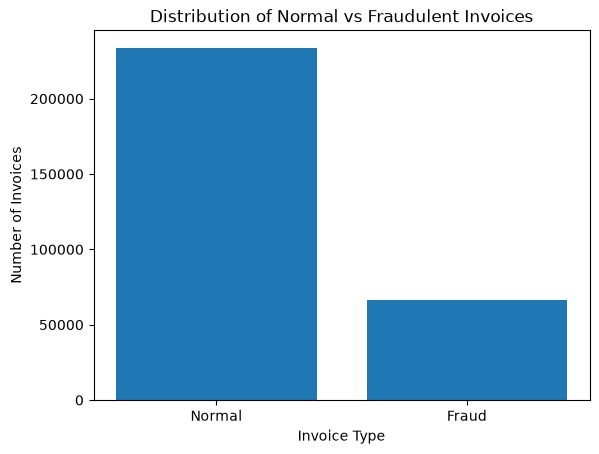

In [50]:
fraud_counts = data["is_fraud"].value_counts().sort_index()

plt.bar(["Normal", "Fraud"], fraud_counts.values)
plt.title("Distribution of Normal vs Fraudulent Invoices")
plt.xlabel("Invoice Type")
plt.ylabel("Number of Invoices")
plt.show()

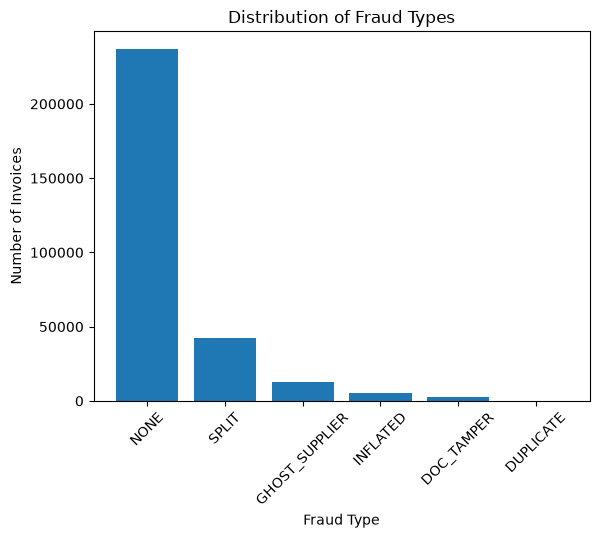

In [51]:
fraud_type_counts = data["fraud_type"].value_counts()

plt.bar(fraud_type_counts.index, fraud_type_counts.values)
plt.title("Distribution of Fraud Types")
plt.xlabel("Fraud Type")
plt.ylabel("Number of Invoices")
plt.xticks(rotation=45)
plt.show()

In [52]:
data.groupby("is_fraud")["invoice_amount"].mean()

is_fraud
0    7427.770754
1    8046.373192
Name: invoice_amount, dtype: float64

In [53]:
data.groupby("is_fraud")["invoice_amount"].median()

is_fraud
0    5452.505
1    2925.380
Name: invoice_amount, dtype: float64

In [54]:
data.groupby("fraud_type")["invoice_amount"].median().sort_values()

fraud_type
SPLIT              1966.555
DUPLICATE          2506.300
DOC_TAMPER         5010.570
NONE               5467.600
GHOST_SUPPLIER     5738.670
INFLATED          43510.050
Name: invoice_amount, dtype: float64

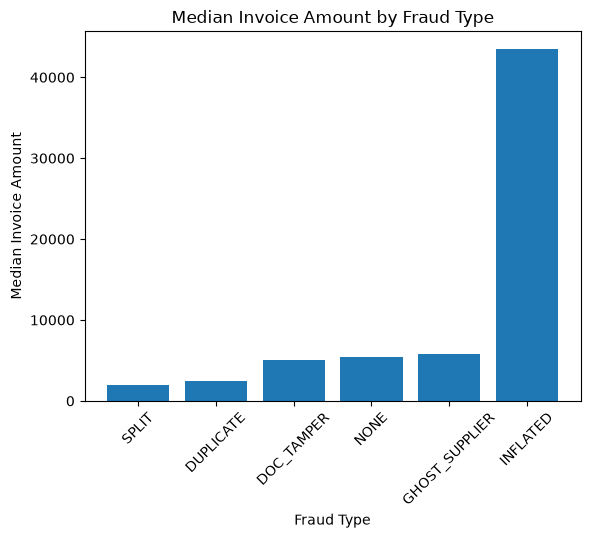

In [55]:
median_amounts = (
    data.groupby("fraud_type")["invoice_amount"]
    .median()
    .sort_values()
)

plt.bar(median_amounts.index, median_amounts.values)
plt.title("Median Invoice Amount by Fraud Type")
plt.xlabel("Fraud Type")
plt.ylabel("Median Invoice Amount")
plt.xticks(rotation=45)
plt.show()

In [56]:
data.groupby("is_fraud")["supplier_risk_score"].mean()

is_fraud
0    0.284062
1    0.297086
Name: supplier_risk_score, dtype: float64

In [57]:
data.groupby("fraud_type")["supplier_risk_score"].mean().sort_values()

fraud_type
DUPLICATE         0.260943
GHOST_SUPPLIER    0.279801
SPLIT             0.283525
NONE              0.284012
INFLATED          0.288725
DOC_TAMPER        0.674393
Name: supplier_risk_score, dtype: float64

In [58]:
pd.crosstab(data["blacklisted_flag"], data["fraud_type"])

fraud_type,DOC_TAMPER,DUPLICATE,GHOST_SUPPLIER,INFLATED,NONE,SPLIT
blacklisted_flag,,,,,,
0,2207,66,0,5121,237036,40202
1,172,4,12588,460,0,2144


In [59]:
data.groupby("is_fraud")["submission_hour"].mean()

is_fraud
0    11.559305
1    11.224710
Name: submission_hour, dtype: float64

In [60]:
fraud_by_hour = data.groupby("submission_hour")["is_fraud"].mean() * 100

fraud_by_hour

submission_hour
0     23.906237
1     23.901187
2     23.563400
3     24.080721
4     23.884430
5     24.508249
6     21.031433
7     21.493803
8     21.721571
9     21.919007
10    21.979587
11    21.668644
12    21.875500
13    20.913519
14    21.670411
15    21.634886
16    21.556789
17    21.386909
18    21.939472
19    21.410091
20    21.662529
21    20.842924
22    21.663302
23    21.039702
Name: is_fraud, dtype: float64

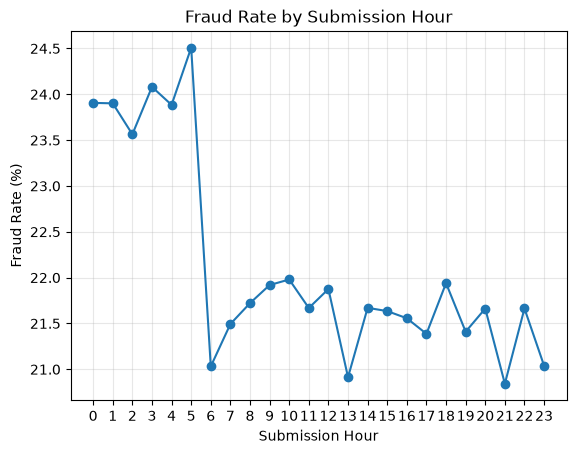

In [61]:
plt.plot(fraud_by_hour.index, fraud_by_hour.values, marker="o")
plt.title("Fraud Rate by Submission Hour")
plt.xlabel("Submission Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.show()

In [62]:
data["invoice_type"].value_counts()

invoice_type
GOODS       164863
SERVICES    135137
Name: count, dtype: int64

In [63]:
data.groupby("invoice_type")["is_fraud"].mean() * 100

invoice_type
GOODS       22.199645
SERVICES    22.059836
Name: is_fraud, dtype: float64

In [64]:
data["payment_terms"].value_counts()

payment_terms
NET30    180337
NET60     89883
NET90     29780
Name: count, dtype: int64

In [65]:
data.groupby("payment_terms")["is_fraud"].mean() * 100

payment_terms
NET30    22.064801
NET60    22.234460
NET90    22.276696
Name: is_fraud, dtype: float64

In [66]:
data["supplier_age_days"].describe()

count    300000.000000
mean       2259.979440
std        1567.266425
min          30.000000
25%         804.000000
50%        2243.000000
75%        3629.000000
max        4999.000000
Name: supplier_age_days, dtype: float64

In [67]:
data.groupby("is_fraud")["supplier_age_days"].mean()

is_fraud
0    2268.996768
1    2228.261964
Name: supplier_age_days, dtype: float64

In [68]:
data.groupby("fraud_type")["supplier_age_days"].mean().sort_values()

fraud_type
GHOST_SUPPLIER    2068.284716
INFLATED          2242.554739
SPLIT             2262.767652
NONE              2269.284514
DOC_TAMPER        2334.303909
DUPLICATE         2399.628571
Name: supplier_age_days, dtype: float64

In [69]:
data["supplier_country"].nunique()

126

In [70]:
data["supplier_country"].value_counts().head(10)

supplier_country
KZ    6207
IN    6088
DZ    5421
DE    5365
CU    5309
CG    5301
NO    5150
DJ    5114
IQ    5014
MU    4985
Name: count, dtype: int64

In [71]:
country_fraud = data.groupby("supplier_country").agg(
    invoice_count=("invoice_id", "count"),
    fraud_rate=("is_fraud", "mean")
)

country_fraud["fraud_rate"] *= 100

country_fraud.sort_values("fraud_rate", ascending=False).head(10)

,invoice_count,fraud_rate
supplier_country,,
CD,784,48.341837
AU,1651,46.941248
IR,1328,46.762048
NL,1429,35.619314
LA,864,34.722222
TR,2110,34.549763
KG,1067,32.802249
SE,761,32.720105
BW,4392,32.058288


In [72]:
country_fraud.sort_values("fraud_rate").head(10)

,invoice_count,fraud_rate
supplier_country,,
BJ,901,14.539401
BZ,853,15.005862
SV,2405,15.301455
HN,2874,15.553236
UA,1009,15.559960
PE,1546,15.847348
MN,1609,15.848353
KE,3398,15.950559
UY,2736,15.972222


In [73]:
data["region"].nunique()

24

In [74]:
region_fraud = data.groupby("region").agg(
    invoice_count=("invoice_id", "count"),
    fraud_rate=("is_fraud", "mean")
)

region_fraud["fraud_rate"] *= 100

region_fraud.sort_values("fraud_rate", ascending=False)

,invoice_count,fraud_rate
region,,
Tennessee,18017,22.600877
Hawaii,5911,22.568093
Wyoming,12134,22.523488
Oregon,6079,22.520151
Pennsylvania,11791,22.517174
California,6066,22.370590
Louisiana,18126,22.271875
Nevada,18058,22.267139
Michigan,12060,22.238806


In [75]:
data["invoice_amount"].describe()

count    300000.000000
mean       7564.708713
std        8812.143358
min          37.350000
25%        2641.757500
50%        4892.300000
75%        9166.187500
max      294048.720000
Name: invoice_amount, dtype: float64

In [76]:
data["invoice_amount"].quantile([0.90, 0.95, 0.99, 0.999])

0.900    16186.22600
0.950    22779.04950
0.990    42700.31700
0.999    85649.63147
Name: invoice_amount, dtype: float64

In [77]:
data["currency"].value_counts()

## all of them are from ZAR (South african Rand) so we can drop this column as it does not provide any information for the model

currency
ZAR    300000
Name: count, dtype: int64

In [78]:
data.groupby("is_fraud")["annual_budget"].mean()

is_fraud
0    2.255594e+08
1    2.250462e+08
Name: annual_budget, dtype: float64

In [79]:
data.groupby("is_fraud")["supplier_invoice_count_30d"].mean()

is_fraud
0    12.577572
1    12.841033
Name: supplier_invoice_count_30d, dtype: float64

In [80]:
data.groupby("is_fraud")["supplier_avg_amount_90d"].mean()

is_fraud
0    7123.042257
1    9155.066042
Name: supplier_avg_amount_90d, dtype: float64

In [81]:
data.groupby("is_fraud")["supplier_avg_amount_90d"].median()

is_fraud
0    5619.929476
1    6349.010771
Name: supplier_avg_amount_90d, dtype: float64

In [82]:
data.groupby("is_fraud")["invoice_amount_zscore"].mean()

is_fraud
0   -0.015540
1    0.054659
Name: invoice_amount_zscore, dtype: float64

## Feature Selection and Leakage Analysis

Basically, the **28 columns are the result of us combining all the useful tables from the Kaggle dataset into one big table**.

When we downloaded the dataset, it wasn't organized as one file containing everything about every invoice. Instead, the information was separated across several files because each file represented a different kind of information.

The main `invoices.parquet` file contained the basic information about each invoice. For example, it told us the invoice ID, which supplier submitted it, which department it belonged to, the invoice date, invoice amount, currency, payment terms, invoice type, submission hour, and whether an invoice image existed.

Then we had `labels.parquet`. That file contained the fraud information. It told us whether an invoice was fraudulent (`is_fraud`), what type of fraud it was (`fraud_type`), and some additional information such as fraud tags and explanations.

The problem is that these were two separate tables. The invoice information might be in one table, while the answer about whether that invoice was fraudulent was in another.

Fortunately, both tables contained `invoice_id`. So if invoice `INV_00000123` appeared in the invoices table and also appeared in the labels table, we could match those two rows together. That's what a **merge** does.

Then we also had `suppliers.parquet`. Instead of storing supplier information repeatedly for every invoice, the dataset had a separate table describing each supplier. It contained things like the supplier's country, age, risk score, whether the supplier was blacklisted, and average invoice amount.

The invoices table already contained `supplier_id`, and the suppliers table also contained `supplier_id`. So we could use that common ID to attach the correct supplier information to every invoice.

The same idea applied to `departments.parquet`. Each invoice already had a `department_id`, while the departments table contained information about those departments, such as their region and annual budget. We matched them using `department_id`.

Then we had `behavioural_features.parquet`. This contained engineered information about each invoice, such as how many invoices that supplier submitted in the previous 30 days, the supplier's average amount over 90 days, the invoice amount z-score, and flags such as duplicate invoice, split invoice, and late-night submission. That table also contained `invoice_id`, so we matched it to the correct invoice.

Finally, `splits.parquet` told us whether each invoice belongs to the **training, validation, or test dataset**. Again, it contained `invoice_id`, so we attached that information to each invoice too.

After all those merges, instead of having information scattered across several separate files, we ended up with one big DataFrame called **`data`**.

Each **row** in `data` represents one invoice.

Each **column** represents one piece of information we know about that invoice.

So when we ran `data.shape` and got `(300000, 28)`, that meant we had **300,000 invoices and 28 pieces of information about each invoice**.

And when we just ran `data.columns.tolist()`, Python simply showed us the names of those 28 pieces of information.

Importantly, we did **not invent 28 new features ourselves**. Most of those columns already existed in the downloaded dataset. What we did was bring the relevant columns from the different files together into one table.

That's also why the stage we're entering now is important. Just because we have 28 columns does **not** mean all 28 should be given to the machine-learning model. Some are useful information, some are just IDs, some contain no useful variation, some tell us how the dataset is organized, and some potentially reveal the fraud answer itself.

So our next job is essentially:

**"Out of everything we know about an invoice, what information would it be legitimate for an AI system to use when trying to predict whether that invoice is fraudulent?"**

That's what the **Feature Selection and Leakage Analysis** section is going to answer.


In [83]:
y = data["is_fraud"]
#y = the answer we want our machine-learning model to learn to predict (0= normal, 1=fraudulent)

### Columns Excluded from Modeling

Some columns should not be used as model inputs because they either reveal the target, serve only as identifiers or dataset metadata, or contain no predictive information.

- **`is_fraud`** — This is the target variable that the model is trying to predict, so it cannot also be used as an input feature.
- **`fraud_type`**, **`fraud_tags`**, **`explanations`** — These columns contain information about the fraud label itself. Using them would give the model information about the answer and cause data leakage.
- **`invoice_id`** — This is a unique identifier for each invoice rather than meaningful information about the invoice.
- **`image_path`** — This only points to the associated invoice image. Images are outside the scope of the initial tabular model.
- **`currency`** — All 300,000 invoices use ZAR, so this column has no variation and cannot help distinguish fraudulent from normal invoices.
- **`split`** — This indicates whether an invoice belongs to the training, validation, or test set. It is used to organize model development and should not be a predictive feature.

In [84]:
pd.crosstab(data["duplicate_invoice_flag"], data["is_fraud"])

is_fraud,0,1
duplicate_invoice_flag,,
0,233590,66340
1,0,70


In [85]:
pd.crosstab(data["split_invoice_flag"], data["is_fraud"])

is_fraud,0,1
split_invoice_flag,,
0,232711,24610
1,879,41800


In [86]:
pd.crosstab(data["late_night_submission_flag"], data["is_fraud"])

is_fraud,0,1
late_night_submission_flag,,
0,176446,48390
1,57144,18020


In [87]:
pd.crosstab(data["blacklisted_flag"], data["is_fraud"])

is_fraud,0,1
blacklisted_flag,,
0,233296,51336
1,294,15074


### Potential Data Leakage

Several engineered features were investigated to determine whether they were too closely related to the fraud labels. Since the dataset is synthetic and uses rule-based fraud labels, some features may contain information that was directly involved in generating those labels.

The following features were identified for exclusion from the leakage-safe model:

- **`duplicate_invoice_flag`** — Every invoice with this flag was fraudulent (70 fraudulent and 0 normal). This feature therefore provides an almost direct indication of the target.

- **`split_invoice_flag`** — Approximately 98% of invoices with this flag were fraudulent (41,800 fraudulent and 879 normal). The feature is also strongly associated with the SPLIT fraud category, suggesting that it is closely connected to the dataset's fraud-generation rules.

- **`blacklisted_flag`** — Approximately 98% of invoices from blacklisted suppliers were fraudulent (15,074 fraudulent and 294 normal). Earlier analysis also showed that all GHOST_SUPPLIER cases involved blacklisted suppliers, making this feature a potential source of target leakage.

- **`late_night_submission_flag`** — This feature showed a much weaker relationship with fraud, with a fraud rate of approximately 24% for flagged invoices compared with 21.5% for other invoices. However, it is excluded because the original `submission_hour` feature already contains the underlying information. Using the original hour allows the model to learn any relationship between submission time and fraud without relying on a pre-engineered flag.

Removing these features helps create a more realistic leakage-safe model. Otherwise, the model could achieve artificially strong performance by learning rules that were already used to construct the synthetic fraud labels rather than discovering meaningful patterns from the underlying invoice and supplier characteristics.

In [88]:
data.groupby("is_fraud")["supplier_risk_score"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,233590.0,0.284062,0.149440,0.002,0.168,0.267,0.385,0.861
1,66410.0,0.297086,0.167513,0.002,0.166,0.275,0.408,0.861


In [89]:
data[["supplier_id", "department_id"]].nunique()

supplier_id      2000
department_id      50
dtype: int64

In [90]:
train_suppliers = set(data.loc[data["split"] == "train", "supplier_id"])
test_suppliers = set(data.loc[data["split"] == "test", "supplier_id"])

len(train_suppliers & test_suppliers)

2000

### Supplier Identifier

The raw `supplier_id` will not be used directly as a model feature because all 2,000 suppliers appear in both the training and test sets. Using the identifier directly could allow the model to memorize supplier-specific fraud patterns rather than learning generalizable characteristics of suspicious invoices.

However, the supplier identifier can still be useful for feature engineering. A historical supplier fraud rate can be calculated using training data only, representing the proportion of a supplier's previous invoices that were fraudulent. This information may also be used to identify suppliers whose historical fraud rate exceeds a selected risk threshold.

Any supplier-history feature must be constructed without using validation or test labels to prevent data leakage.

In [91]:
train_departments = set(data.loc[data["split"] == "train", "department_id"])
test_departments = set(data.loc[data["split"] == "test", "department_id"])

len(train_departments & test_departments)

50

In [92]:
department_fraud = data.groupby("department_id").agg(
    invoice_count=("invoice_id", "count"),
    fraud_rate=("is_fraud", "mean")
)

department_fraud["fraud_rate"] *= 100

department_fraud.sort_values("fraud_rate", ascending=False)

,invoice_count,fraud_rate
department_id,,
DPT_014,6017,23.167692
DPT_042,6049,23.078195
DPT_002,6045,22.894955
DPT_015,5965,22.883487
DPT_034,5962,22.710500
DPT_039,6103,22.644601
DPT_044,6097,22.617681
DPT_029,5911,22.568093
DPT_043,6079,22.520151


### Department Identifier

All 50 departments appear in both the training and test sets. The raw `department_id` will therefore not be used directly as a model feature, as the model could learn department-specific patterns from repeated identifiers rather than more general characteristics.

Department characteristics such as `region` and `annual_budget` remain available as potential features. Exploratory analysis showed only small differences in fraud rates across regions and department budgets, so no historical department-risk feature will be engineered at this stage.

In [93]:
features = [
    "invoice_date",
    "invoice_amount",
    "payment_terms",
    "invoice_type",
    "submission_hour",
    "supplier_country",
    "supplier_age_days",
    "supplier_risk_score",
    "avg_invoice_amount",
    "region",
    "annual_budget",
    "supplier_invoice_count_30d",
    "supplier_avg_amount_90d",
    "invoice_amount_zscore"
]

In [94]:
X = data[features]
X.shape

(300000, 14)

In [95]:
train_data = data[data["split"] == "train"]

train_data.groupby("supplier_id").size().describe()

count    2000.000000
mean      105.000000
std        10.319557
min        71.000000
25%        98.000000
50%       105.000000
75%       112.000000
max       140.000000
dtype: float64

In [96]:
supplier_history = train_data.groupby("supplier_id").agg(
    historical_invoice_count=("is_fraud", "count"),
    historical_fraud_rate=("is_fraud", "mean")
)

supplier_history["historical_fraud_rate"] *= 100

supplier_history.head()

,historical_invoice_count,historical_fraud_rate
supplier_id,,
004b6fab-fcf5-4188-932e-6dcd83bc9478,92,19.565217
004ea81a-d3d8-47a8-8a0e-a57a9a7d509d,108,12.037037
0066853d-6de2-49a1-8a90-cd0c24c173b9,111,15.315315
008d4127-6104-41e3-aa25-a8880f02bad0,108,25.000000
00a85473-8242-4912-bda3-c1623a78b64a,106,13.207547


In [97]:
supplier_history["historical_fraud_rate"].describe()

count    2000.000000
mean       21.920512
std        19.072768
min         4.854369
25%        13.684211
50%        16.666667
75%        20.567620
max       100.000000
Name: historical_fraud_rate, dtype: float64

In [98]:
pd.cut(
    supplier_history["historical_fraud_rate"],
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    include_lowest=True
).value_counts().sort_index()

historical_fraud_rate
(-0.001, 10.0]      96
(10.0, 20.0]      1369
(20.0, 30.0]       322
(30.0, 40.0]        68
(40.0, 50.0]        28
(50.0, 60.0]         8
(60.0, 70.0]         5
(70.0, 80.0]         3
(80.0, 90.0]         0
(90.0, 100.0]      101
Name: count, dtype: int64

In [99]:
supplier_history.sort_values(
    "historical_fraud_rate",
    ascending=False
).head(20)

,historical_invoice_count,historical_fraud_rate
supplier_id,,
2cf149cb-4f1e-4a37-8ac8-ad937e02921d,108,100.000000
0b3d0c36-17d0-4810-87a2-a10bb62edb49,103,100.000000
ba6c34ab-6712-403a-8f84-4fef1931e9ee,101,100.000000
67443fb8-81bd-45d5-b5a6-571c4fa5c35e,126,100.000000
64988bde-cd02-44db-ad11-15d750a46c85,117,100.000000
43ff5011-3d1a-45dd-906e-5a9ab758588d,99,100.000000
58007c02-87ea-4ff5-8db0-674679279973,132,100.000000
5c63b6f3-06ba-4cd3-be78-38c9ca55e38b,106,100.000000
103056b7-9e4c-44dd-b864-a47ba43447fb,103,100.000000


In [100]:
high_risk_supplier_ids = supplier_history[
    supplier_history["historical_fraud_rate"] >= 90
].index

data[
    data["supplier_id"].isin(high_risk_supplier_ids)
]["fraud_type"].value_counts()

fraud_type
GHOST_SUPPLIER    12588
SPLIT              2144
INFLATED            460
DOC_TAMPER          172
DUPLICATE             4
Name: count, dtype: int64

In [101]:
data["invoice_date"].dtype

dtype('<M8[ns]')

In [102]:
data["invoice_date"].min(), data["invoice_date"].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2023-12-31 00:00:00'))

In [103]:
data["invoice_date"].value_counts().describe()

count    365.000000
mean     821.917808
std       29.023652
min      715.000000
25%      804.000000
50%      822.000000
75%      841.000000
max      915.000000
Name: count, dtype: float64

In [104]:
same_hour_counts = data.groupby(
    ["supplier_id", "invoice_date", "submission_hour"]
).size()

same_hour_counts[same_hour_counts > 1].describe()

count    2549.000000
mean        2.006277
std         0.078994
min         2.000000
25%         2.000000
50%         2.000000
75%         2.000000
max         3.000000
dtype: float64

In [105]:
data["submission_datetime"] = (
    data["invoice_date"]
    + pd.to_timedelta(data["submission_hour"], unit="h")
)

data[
    ["invoice_date", "submission_hour", "submission_datetime"]
].head()

,invoice_date,submission_hour,submission_datetime
0,2023-04-18,18,2023-04-18 18:00:00
1,2023-10-08,6,2023-10-08 06:00:00
2,2023-09-24,23,2023-09-24 23:00:00
3,2023-10-15,7,2023-10-15 07:00:00
4,2023-06-07,12,2023-06-07 12:00:00


In [106]:
data_chronological = data.sort_values(
    ["supplier_id", "submission_datetime"]
).copy()

data_chronological[
    ["supplier_id", "submission_datetime", "is_fraud"]
].head(10)

,supplier_id,submission_datetime,is_fraud
138003,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-02 20:00:00,0
153155,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-07 22:00:00,0
34829,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-11 09:00:00,0
72998,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-13 18:00:00,1
211525,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-17 09:00:00,1
287780,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-18 12:00:00,0
142798,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-20 01:00:00,0
16168,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-24 02:00:00,0
3320,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-26 09:00:00,1
143170,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-26 09:00:00,0


In [107]:
supplier_hourly = (
    data_chronological
    .groupby(["supplier_id", "submission_datetime"])
    .agg(
        invoices_in_hour=("is_fraud", "count"),
        frauds_in_hour=("is_fraud", "sum")
    )
    .reset_index()
)

supplier_hourly.head(10)

,supplier_id,submission_datetime,invoices_in_hour,frauds_in_hour
0,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-02 20:00:00,1,0
1,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-07 22:00:00,1,0
2,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-11 09:00:00,1,0
3,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-13 18:00:00,1,1
4,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-17 09:00:00,1,1
5,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-18 12:00:00,1,0
6,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-20 01:00:00,1,0
7,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-24 02:00:00,1,0
8,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-26 09:00:00,2,1
9,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-28 23:00:00,1,0


In [108]:
supplier_hourly["previous_invoice_count"] = (
    supplier_hourly
    .groupby("supplier_id")["invoices_in_hour"]
    .cumsum()
    - supplier_hourly["invoices_in_hour"]
)

supplier_hourly["previous_fraud_count"] = (
    supplier_hourly
    .groupby("supplier_id")["frauds_in_hour"]
    .cumsum()
    - supplier_hourly["frauds_in_hour"]
)

supplier_hourly[
    [
        "supplier_id",
        "submission_datetime",
        "invoices_in_hour",
        "frauds_in_hour",
        "previous_invoice_count",
        "previous_fraud_count"
    ]
].head(10)

,supplier_id,submission_datetime,invoices_in_hour,frauds_in_hour,previous_invoice_count,previous_fraud_count
0,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-02 20:00:00,1,0,0,0
1,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-07 22:00:00,1,0,1,0
2,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-11 09:00:00,1,0,2,0
3,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-13 18:00:00,1,1,3,0
4,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-17 09:00:00,1,1,4,1
5,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-18 12:00:00,1,0,5,2
6,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-20 01:00:00,1,0,6,2
7,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-24 02:00:00,1,0,7,2
8,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-26 09:00:00,2,1,8,2
9,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-28 23:00:00,1,0,10,3


In [109]:
supplier_hourly["historical_fraud_rate"] = (
    supplier_hourly["previous_fraud_count"]
    / supplier_hourly["previous_invoice_count"]
    * 100
)

supplier_hourly[
    [
        "supplier_id",
        "submission_datetime",
        "previous_invoice_count",
        "previous_fraud_count",
        "historical_fraud_rate"
    ]
].head(10)

,supplier_id,submission_datetime,previous_invoice_count,previous_fraud_count,historical_fraud_rate
0,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-02 20:00:00,0,0,NaN
1,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-07 22:00:00,1,0,0.000000
2,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-11 09:00:00,2,0,0.000000
3,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-13 18:00:00,3,0,0.000000
4,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-17 09:00:00,4,1,25.000000
5,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-18 12:00:00,5,2,40.000000
6,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-20 01:00:00,6,2,33.333333
7,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-24 02:00:00,7,2,28.571429
8,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-26 09:00:00,8,2,25.000000
9,004b6fab-fcf5-4188-932e-6dcd83bc9478,2023-01-28 23:00:00,10,3,30.000000


In [110]:
supplier_hourly["previous_invoice_count"].describe()

count    297435.000000
mean         74.992099
std          44.154117
min           0.000000
25%          37.000000
50%          74.000000
75%         112.000000
max         200.000000
Name: previous_invoice_count, dtype: float64

In [111]:
(supplier_hourly["previous_invoice_count"] < 10).value_counts()

previous_invoice_count
False    277585
True      19850
Name: count, dtype: int64

In [112]:
def supplier_priority(row):
    if row["previous_invoice_count"] < 10:
        return "Insufficient History"
    elif row["historical_fraud_rate"] >= 90:
        return "Critical"
    elif row["historical_fraud_rate"] >= 30:
        return "High"
    else:
        return "Normal"

supplier_hourly["supplier_priority"] = supplier_hourly.apply(
    supplier_priority,
    axis=1
)

supplier_hourly["supplier_priority"].value_counts()

supplier_priority
Normal                  245433
Insufficient History     19850
High                     17983
Critical                 14169
Name: count, dtype: int64

In [113]:
supplier_hourly[
    [
        "previous_invoice_count",
        "previous_fraud_count",
        "historical_fraud_rate",
        "supplier_priority"
    ]
].groupby("supplier_priority").head(3)

,previous_invoice_count,previous_fraud_count,historical_fraud_rate,supplier_priority
0,0,0,NaN,Insufficient History
1,1,0,0.000000,Insufficient History
2,2,0,0.000000,Insufficient History
9,10,3,30.000000,High
10,11,3,27.272727,Normal
11,12,3,25.000000,Normal
12,13,3,23.076923,Normal
458,10,3,30.000000,High
2071,10,3,30.000000,High
9419,10,9,90.000000,Critical


In [114]:
history_columns = supplier_hourly[
    [
        "supplier_id",
        "submission_datetime",
        "previous_invoice_count",
        "previous_fraud_count",
        "historical_fraud_rate",
        "supplier_priority"
    ]
]

data = data.merge(
    history_columns,
    on=["supplier_id", "submission_datetime"],
    how="left"
)

data.shape

(300000, 33)

In [115]:
data[
    [
        "supplier_id",
        "submission_datetime",
        "previous_invoice_count",
        "previous_fraud_count",
        "historical_fraud_rate",
        "supplier_priority",
        "is_fraud"
    ]
].head(10)

,supplier_id,submission_datetime,previous_invoice_count,previous_fraud_count,historical_fraud_rate,supplier_priority,is_fraud
0,7316ce64-2a14-4a96-9b0c-62eb27c8fc6c,2023-04-18 18:00:00,43,10,23.255814,Normal,0
1,7428a656-b3ee-4d3b-9a10-412954aebd1b,2023-10-08 06:00:00,114,21,18.421053,Normal,0
2,7b0ccad9-eee1-4cae-b02e-21aa352b6ec8,2023-09-24 23:00:00,113,17,15.044248,Normal,0
3,1c6345ab-6e0e-41e8-985d-3f861d2324e6,2023-10-15 07:00:00,113,20,17.699115,Normal,1
4,22d839d3-33e4-4986-b18c-ccdc131eb723,2023-06-07 12:00:00,54,2,3.703704,Normal,0
5,ff84faef-5336-423b-8f96-468535145890,2023-03-19 06:00:00,27,1,3.703704,Normal,0
6,7a1b5806-6160-46b4-9360-715fc3fe0183,2023-08-10 14:00:00,89,12,13.483146,Normal,1
7,004ea81a-d3d8-47a8-8a0e-a57a9a7d509d,2023-12-01 15:00:00,147,19,12.925170,Normal,0
8,d2d33488-d0c3-4018-ae3c-dd4f55b145e4,2023-01-03 03:00:00,0,0,NaN,Insufficient History,0
9,d7665cda-fe04-4059-b985-fb6217dc8eff,2023-07-20 01:00:00,97,15,15.463918,Normal,0


### Historical Supplier Risk and Audit Priority

The raw `supplier_id` is not used directly as a predictive feature. Instead, it is used to construct a historical supplier-risk measure based on previously observed invoices.

For each invoice, the supplier's history is calculated using only invoices submitted during earlier time periods. The `invoice_date` and `submission_hour` columns are combined to create an hourly submission timestamp. When multiple invoices from the same supplier occur within the same hour, they are treated as arriving simultaneously because the dataset does not provide minute- or second-level timestamps. Therefore, invoices within the same hour cannot use each other's outcomes as historical information.

Three historical variables are constructed:

- `previous_invoice_count`: number of invoices previously observed from the supplier.
- `previous_fraud_count`: number of those previous invoices identified as fraudulent.
- `historical_fraud_rate`: percentage of previous invoices identified as fraudulent.

After an invoice has been assessed and its outcome becomes known, it contributes to the supplier history available for later invoices. This prevents the current invoice or future invoices from being used to calculate its own historical risk and avoids temporal data leakage.

A supplier audit-priority system is also constructed:

- **Insufficient History:** fewer than 10 previous invoices.
- **Normal:** at least 10 previous invoices and a historical fraud rate below 30%.
- **High:** at least 10 previous invoices and a historical fraud rate from 30% to below 90%.
- **Critical:** at least 10 previous invoices and a historical fraud rate of 90% or higher.

The priority level is intended as an audit-support signal rather than proof of fraud. A supplier's priority can change over time as additional invoice outcomes become available.

In [116]:
data[
    [
        "previous_invoice_count",
        "previous_fraud_count",
        "historical_fraud_rate",
        "supplier_priority"
    ]
].isnull().sum()

previous_invoice_count       0
previous_fraud_count         0
historical_fraud_rate     2011
supplier_priority            0
dtype: int64

In [117]:
data["historical_fraud_rate_filled"] = (
    data["historical_fraud_rate"].fillna(0)
)

data["historical_fraud_rate_filled"].isnull().sum()

np.int64(0)

In [118]:
features += [
    "previous_invoice_count",
    "historical_fraud_rate_filled"
]

len(features)

16

In [119]:
data["zscore_above_3"] = data["invoice_amount_zscore"] >= 3

pd.crosstab(
    data["zscore_above_3"],
    data["fraud_type"]
)

fraud_type,DOC_TAMPER,DUPLICATE,GHOST_SUPPLIER,INFLATED,NONE,SPLIT
zscore_above_3,,,,,,
False,2294,70,12588,0,237036,42345
True,85,0,0,5581,0,1


In [120]:
len(features)

16

In [121]:
features

['invoice_date',
 'invoice_amount',
 'payment_terms',
 'invoice_type',
 'submission_hour',
 'supplier_country',
 'supplier_age_days',
 'supplier_risk_score',
 'avg_invoice_amount',
 'region',
 'annual_budget',
 'supplier_invoice_count_30d',
 'supplier_avg_amount_90d',
 'invoice_amount_zscore',
 'previous_invoice_count',
 'historical_fraud_rate_filled']

In [122]:
X = data[features].copy()
X.shape

(300000, 16)

In [123]:
X = data[features].copy()
X.columns

Index(['invoice_date', 'invoice_amount', 'payment_terms', 'invoice_type',
       'submission_hour', 'supplier_country', 'supplier_age_days',
       'supplier_risk_score', 'avg_invoice_amount', 'region', 'annual_budget',
       'supplier_invoice_count_30d', 'supplier_avg_amount_90d',
       'invoice_amount_zscore', 'previous_invoice_count',
       'historical_fraud_rate_filled'],
      dtype='str')

In [124]:
X["invoice_month"] = X["invoice_date"].dt.month
X["invoice_day_of_week"] = X["invoice_date"].dt.dayofweek

X = X.drop(columns=["invoice_date"])

In [125]:
X.shape

(300000, 17)

In [126]:
X.select_dtypes(include="object").columns

C:\Users\omala\AppData\Local\Temp\ipykernel_9864\2213039483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['payment_terms', 'invoice_type', 'supplier_country', 'region'], dtype='str')

In [127]:
X_encoded = pd.get_dummies(
    X,
    columns=["payment_terms", "invoice_type", "supplier_country", "region"],
    drop_first=False
)

In [128]:
X_encoded.shape

(300000, 168)

In [129]:
X_encoded.isnull().sum().sum()

np.int64(0)

In [130]:
data["split"].value_counts()

split
train    210000
test      60000
val       30000
Name: count, dtype: int64

In [131]:
train_mask = data["split"] == "train"
val_mask = data["split"] == "val"
test_mask = data["split"] == "test"

X_train = X_encoded[train_mask]
X_val = X_encoded[val_mask]
X_test = X_encoded[test_mask]

y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

In [132]:
X_train.shape, X_val.shape, X_test.shape

((210000, 168), (30000, 168), (60000, 168))

In [133]:
print("Train fraud rate:", y_train.mean() * 100)
print("Validation fraud rate:", y_val.mean() * 100)
print("Test fraud rate:", y_test.mean() * 100)

Train fraud rate: 21.965238095238096
Validation fraud rate: 22.576666666666668
Test fraud rate: 22.516666666666666
